# Manual Implementation of Deep Learning

[Use numpy for all questions]

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

## Linear Regression
**We will do a linear regression using backpropagartion.**
*Of course, there is an analyctical solution to this problem, but the techniques used can be generalized to complex models (like actual neural networks), for which we do not have an analyctical solution to compute the optimal weights.* We forget about activation functions for now because we do not need non-linearity (we are trying to fit a linear function!).

Create $N \in \mathbb{N}$ points of data $x_i, 0 \leq i < N$ with $x_i \in [0,1)$ and associated (noised) output $y_i = a*x_i+b+\epsilon_i$ with $\epsilon_i \approx \mathcal{N}(0,0.01)$. Use the function `np.random.randn`.

Use $a=2$, $b=1$ & $N=100$

In [2]:
A = 2
B = 1
N = 100
eps = 0.1
xs = np.linspace(0, 1, N)
ys = A*xs + B + np.random.randn(N)*eps

Plot the dots to check it makes sense to use a linear model

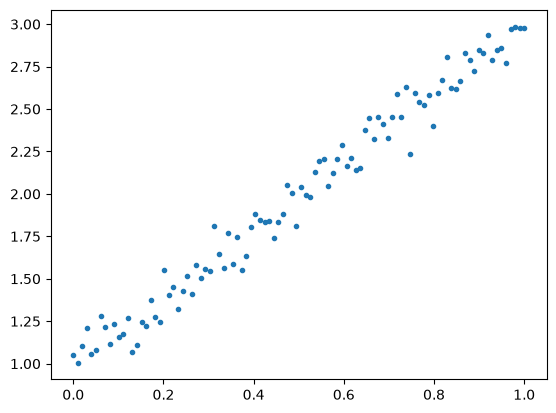

In [3]:
plt.plot(xs, ys, '.')

Initialize parameters $a$ and $b$ randomly (this is our first guess of a and b, obviously wrong, but we need to initialize them to start the training converging to the right values).

In [4]:
a = np.random.randn()
b = np.random.randn()
a,b

(-1.4153707420504142, -0.42064532276535904)

Calculate your predictions $\hat{y} = a * x_{train} +b$

In [5]:
yhat = a * xs + b


Calculate the error $err = \hat{y} - y_{train}$ and the MSE loss defined as:

$loss = \frac{err^2}{N}$ (dividing by $N$ is not actually necessary)

In [6]:
err = yhat - ys
loss = np.sum(err**2) / N
print(loss)

10.729463627310146


Compute the gradients for both the $a$ and $b$ parameters

In [7]:
a_grad = np.sum( (2*(a*xs+b - ys)*xs ))/N
b_grad = np.sum( 2*(a*xs+b - ys) )/N
a_grad, b_grad

(np.float64(-3.7010193837146153), np.float64(-6.235892084102314))

Update parameters using gradients and the learning rate `lr = 1e-1`

In [8]:
lr = 0.1
a = a - lr*a_grad
b = b - lr*b_grad


Repeat this for $1000$ epochs and plot error as a function of epoch

2.0125203525427473 0.9834009132128643


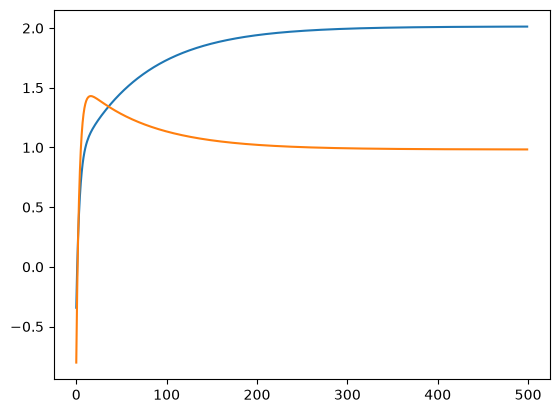

In [9]:
a = np.random.randn()
b = np.random.randn()
lr = 0.1

a_hist = []
b_hist = []

for _ in range(500):
    a_hist.append(a)
    b_hist.append(b)
    yhat = a * xs + b
    err = yhat - ys
    loss = np.sum(err**2) / N
    a_grad = np.sum( 2*(a*xs+b - ys)*xs )/N
    b_grad = np.sum( 2*(a*xs+b - ys) )/N
    a = a - lr*a_grad
    b = b - lr*b_grad


print(a, b)
plt.plot(a_hist)
plt.plot(b_hist)

Check that we get the same results as our gradient descent with an analytical linear regression (you may use `sklearn.linear_model.LinearRegression`)

In [10]:
import sklearn
import sklearn.linear_model

reg = sklearn.linear_model.LinearRegression()
reg.fit(xs.reshape(N,1),ys.reshape(N,1))
reg.coef_, reg.intercept_

(array([[2.01379327]]), array([0.98271871]))

-----

## $XOR$
**We will create a (simple) neural network with 2 layers to fit the $XOR$ function.**

*Of course, this is dumb since the xor function is (much) faster than running a neural network; but the technique can be used to fit complex functions, for which we may not even have an expression.*

You can try manually training a neural network to behave like an xor logical door with this interactive tool:
https://pauldubois98.github.io/TrainingAI/TrainNeuralNetwork.html


Other live challenges (with solutions) available here:
https://pauldubois98.github.io/TrainingAI/


Define the $XOR$ function and create some synthetic training data

In [11]:
def xor(a,b):
    return int((a and not b) or (b and not a))
xs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])
ys = np.array([xor(a,b) for a,b in xs])
print(xs)
print(ys)

[[0 0]
 [0 1]
 [1 0]
 [1 1]]
[0 1 1 0]


Define the model's architecture and some hyperparameters:
- $10$ hidden units
- learning rate of $0.2$
- 10_000 epochs

In [12]:
N_hidden = 10
lr = 0.2
N_epochs = 10_000

Define the model's weight matrices and biases.

Depending on how you perform the calculation between one layer and the other of the neural network ($l_{n} = Wl_{n-1} + b_n$ or $l_{n} = l_{n-1}W + b_n$), the number of rows and columns of W might be inverted.

In [13]:
x = xs[0]
W1 = np.random.randn(N_hidden, 2)
b1 = np.random.randn(N_hidden)
W2 = np.random.randn(1,N_hidden)
b2 = np.random.randn()
pre_l1 = W1 @ x + b1
# l1 = sigmoid(pre_l1)
# pre_l2 = W2 @ l1 + b2
# out = sigmoid(pre_l2)

pre_l1



array([ 0.58685709,  2.19045563, -0.99053633, -0.56629773,  0.09965137,
       -0.50347565, -1.55066343,  0.06856297, -1.06230371,  0.47359243])

Define the sigmoid ($\forall x \in \mathbb{R} \: \sigma (x) = \frac{1}{1+e^{-x}}$) activation function and its derivative: 

$\forall x \in \mathbb{R} \:, \sigma'(x) =  \sigma (x) * (1-\sigma (x))$.

In [14]:
def sigmoid(x):
    return 1 / (1+np.exp(-x))
def d_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))


Define the forward pass of the model

In [15]:
x = xs[3]
pre_l1 = W1 @ x + b1
l1 = sigmoid(pre_l1)
pre_l2 = W2 @ l1 + b2
out = sigmoid(pre_l2)
out

array([0.88502918])

Test your model & plot its outputs

[array([0.75291823]),
 array([0.84158647]),
 array([0.81595489]),
 array([0.88502918])]

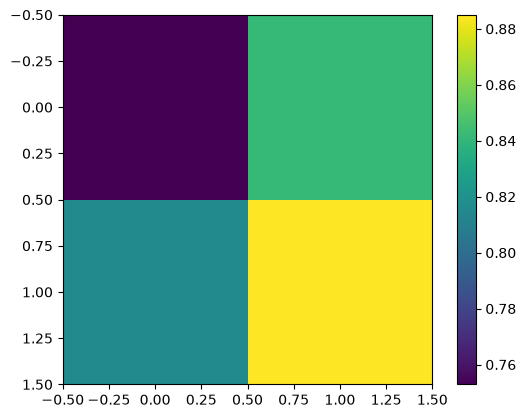

In [16]:
yhat = []
for x in xs:
    pre_l1 = W1 @ x + b1
    l1 = sigmoid(pre_l1)
    pre_l2 = W2 @ l1 + b2
    out = sigmoid(pre_l2)
    yhat.append(out)

plt.imshow(np.array(yhat).reshape(2,2))
plt.colorbar()
yhat


Define the backward pass of the model

In [17]:
x = xs[0]
(W1 @ x).shape


(10,)

In [18]:
pre_l1 = W1 @ xs.T + b1[:, None]
l1 = sigmoid(pre_l1)
pre_l2 = W2 @ l1 + b2
out = sigmoid(pre_l2)
err = out - ys
loss = np.sum(err**2) / N
loss

out_grad = 2*(err) / N
W2_grad = l1 @ out_grad.T
b2_grad = np.sum(out_grad, axis=1)
l1_grad = out_grad.T @ W2
pre_l1_grad = l1_grad.T * d_sigmoid(pre_l1)
W1_grad = pre_l1_grad @ xs
b1_grad = pre_l1_grad.sum(axis=1)


In [19]:
def backward_pass(xs, ys):
    N = len(xs)
    pre_l1 = W1 @ xs.T + b1[:, None]
    l1 = sigmoid(pre_l1)
    pre_l2 = W2 @ l1 + b2
    out = sigmoid(pre_l2)
    err = out - ys
    loss = np.sum(err**2) / N

    out_grad = 2*(err) / N
    W2_grad = l1 @ out_grad.T
    b2_grad = np.sum(out_grad, axis=1)
    l1_grad = out_grad.T @ W2
    pre_l1_grad = l1_grad.T * d_sigmoid(pre_l1)
    W1_grad = pre_l1_grad @ xs
    b1_grad = pre_l1_grad.sum(axis=1)

    return W1_grad, b1_grad, W2_grad, b2_grad, loss

backward_pass(xs, ys)

(array([[-0.06581847, -0.07166264],
        [ 0.00715933, -0.00013858],
        [-0.05813112, -0.06210435],
        [-0.00778908, -0.00404486],
        [ 0.00411429,  0.01842933],
        [-0.10586277, -0.10688426],
        [ 0.00271042,  0.00461908],
        [ 0.04117565,  0.04046976],
        [-0.09154612, -0.11419686],
        [ 0.01736097,  0.01634854]]),
 array([-0.13092894,  0.05032061, -0.10453071, -0.02994561,  0.07620717,
        -0.19053708,  0.01402737,  0.14207936, -0.19340369,  0.0308295 ]),
 array([[0.43662136],
        [0.61198982],
        [0.18826546],
        [0.13424904],
        [0.48695235],
        [0.25377773],
        [0.07181947],
        [0.45681319],
        [0.15117429],
        [0.40253878]]),
 array([0.64774438]),
 np.float64(0.35228248692443054))

Performs the forward pass, backward pass, and weight updates for $10000$ epochs;
in addition:
- print the loss every $1000$ epochs
- save the losses and plot them in a semilogy

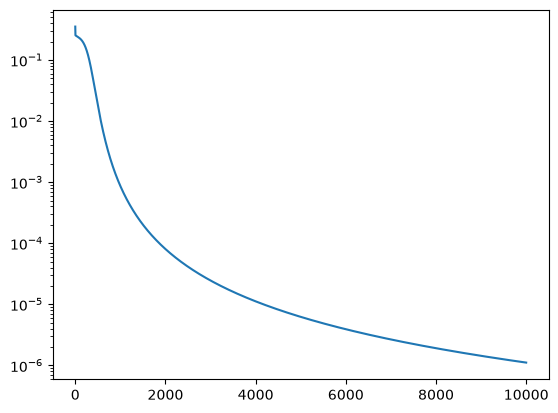

In [20]:
hist = []
for i in range(N_epochs):
    W1_grad, b1_grad, W2_grad, b2_grad, loss = backward_pass(xs, ys)
    W1 = W1 - lr * W1_grad
    W2 = W2 - lr * W2_grad.T
    b1 = b1 - lr * b1_grad
    b2 = b2 - lr * b2_grad
    hist.append(loss)

plt.semilogy(hist)

Test your model & plot its outputs

[array([0.00068086]),
 array([0.99888117]),
 array([0.99897954]),
 array([0.00129625])]

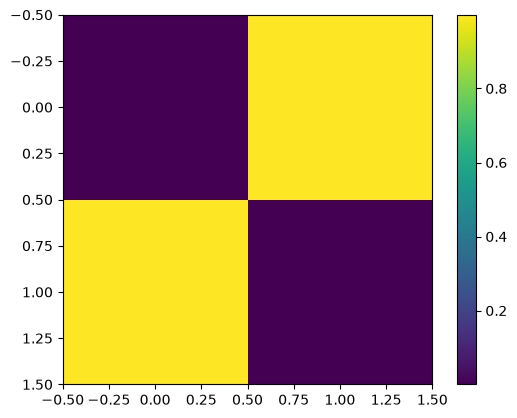

In [21]:
yhat = []
for x in xs:
    pre_l1 = W1 @ x + b1
    l1 = sigmoid(pre_l1)
    pre_l2 = W2 @ l1 + b2
    out = sigmoid(pre_l2)
    yhat.append(out)

plt.imshow(np.array(yhat).reshape(2,2))
plt.colorbar()
yhat


Re-build your model using $ReLU$ activation instead of sigmoid (same number of hidden units, you may need to adjust the learning rate to $0.01$); which activation function converges the fastest?

In [23]:
x = np.arange(10)
x.clip(3, 7)

array([3, 3, 3, 3, 4, 5, 6, 7, 7, 7])

In [ ]:
def relu(x):
    return x.clip(0, None)

def d_relu(x):
    return x>0


If one activation function converges faster, does that mean it is better?

*Answer:*

Re-build your model using the identity activation function everywhere. What happens? Why does it make sense?

Create a network that has ReLU activation on the output as well as in the hidden layer. Try a few different seeds. What happens? Why?

*Hint: for a run that gets stuck, print the output layer's pre-activations and the gradients.*

*Answer:*